# IELTS Performance Prediction — Model Training & Evaluation


In [3]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from src.preprocessing import load_data, split_features_target, split_data, scale_features
from src.feature_engineering import add_composite_features
from src.train import MODELS, train_model, cross_validate_model, save_model
from src.evaluate import evaluate_model, build_comparison_table, print_results

os.makedirs('../results', exist_ok=True)
os.makedirs('../models', exist_ok=True)
sns.set_theme(style='whitegrid')
%matplotlib inline

## 1. Load & Prepare Data


In [4]:
df = load_data('../data/raw/dataset.csv')
df = add_composite_features(df)
X, y = split_features_target(df)
X_train, X_test, y_train, y_test = split_data(X, y)
X_train_sc, X_test_sc, scaler = scale_features(X_train, X_test)
print(f'Train: {X_train.shape} | Test: {X_test.shape}')

Train: (4000, 12) | Test: (1000, 12)


## 2. Train All Models & 5-Fold Cross-Validation


In [5]:
cv_results = {}
test_results = {}
trained_models = {}

for name, model in MODELS.items():
    print(f'Training {name}...')
    # Linear Regression benefits from scaling; tree models don't need it
    X_tr = X_train_sc if name == 'Linear Regression' else X_train
    X_te = X_test_sc  if name == 'Linear Regression' else X_test
    X_cv = X_train_sc if name == 'Linear Regression' else X_train

    trained = train_model(model, X_tr, y_train)
    trained_models[name] = trained

    cv_results[name] = cross_validate_model(model, X_cv, y_train, cv=5)
    test_results[name] = evaluate_model(trained, X_te, y_test)

    print(f'  CV RMSE: {cv_results[name]["cv_rmse_mean"]} ± {cv_results[name]["cv_rmse_std"]}')
    print(f'  Test  R²: {test_results[name]["R2"]}')
    print()

Training Linear Regression...
  CV RMSE: 0.1515 ± 0.0037
  Test  R²: 0.9828

Training Random Forest...
  CV RMSE: 0.167 ± 0.0024
  Test  R²: 0.9803

Training XGBoost...
  CV RMSE: 0.1612 ± 0.0038
  Test  R²: 0.9815



## 3. Results Comparison Table


In [6]:
combined = {}
for name in MODELS:
    combined[name] = {**test_results[name], **cv_results[name]}

results_df = build_comparison_table(combined)
results_df.to_csv('../results/model_comparison.csv')
print_results(combined)
results_df


=== Model Comparison ===
                     RMSE     MAE      R2  cv_rmse_mean  cv_rmse_std  cv_r2_mean  cv_r2_std
Model                                                                                      
Linear Regression  0.1595  0.1292  0.9828        0.1515       0.0037      0.9853     0.0010
Random Forest      0.1706  0.1370  0.9803        0.1670       0.0024      0.9821     0.0007
XGBoost            0.1651  0.1344  0.9815        0.1612       0.0038      0.9833     0.0010



,RMSE,MAE,R2,cv_rmse_mean,cv_rmse_std,cv_r2_mean,cv_r2_std
Model,,,,,,,
Linear Regression,0.1595,0.1292,0.9828,0.1515,0.0037,0.9853,0.0010
Random Forest,0.1706,0.1370,0.9803,0.1670,0.0024,0.9821,0.0007
XGBoost,0.1651,0.1344,0.9815,0.1612,0.0038,0.9833,0.0010


## 4. Model Comparison Bar Chart


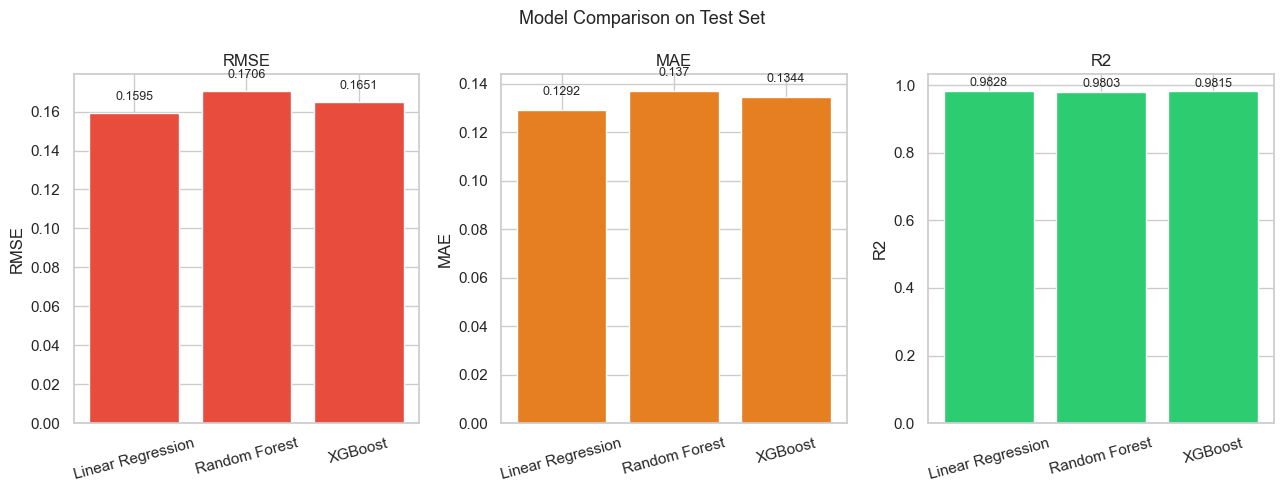

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13, 5))
metrics = ['RMSE', 'MAE', 'R2']
colors = ['#e74c3c', '#e67e22', '#2ecc71']

for ax, metric, color in zip(axes, metrics, colors):
    vals = [test_results[m][metric] for m in MODELS]
    bars = ax.bar(list(MODELS.keys()), vals, color=color, edgecolor='white')
    ax.set_title(metric)
    ax.set_ylabel(metric)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                str(val), ha='center', va='bottom', fontsize=9)
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Model Comparison on Test Set', fontsize=13)
plt.tight_layout()
plt.savefig('../results/model_comparison.png', dpi=150)
plt.show()

## 5. XGBoost Feature Importance


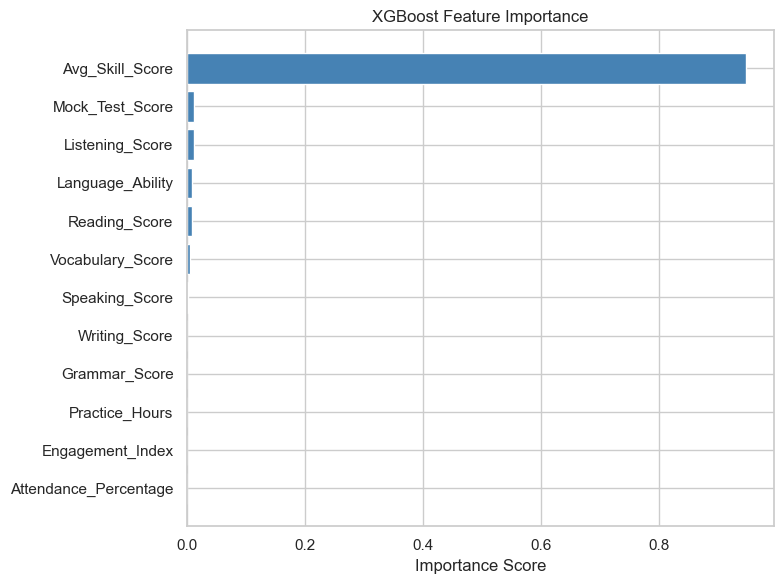

In [8]:
xgb_model = trained_models['XGBoost']
feature_names = list(X_train.columns)
importances = xgb_model.feature_importances_

feat_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(feat_df['Feature'], feat_df['Importance'], color='steelblue', edgecolor='white')
ax.set_xlabel('Importance Score')
ax.set_title('XGBoost Feature Importance')
plt.tight_layout()
plt.savefig('../results/feature_importance.png', dpi=150)
plt.show()

## 6. Save Best Model


In [9]:
best_model_name = min(test_results, key=lambda m: test_results[m]['RMSE'])
print(f'Best model: {best_model_name}')
save_model(trained_models[best_model_name], '../models/best_model.pkl')

import joblib
joblib.dump(scaler, '../models/scaler.pkl')
print('Scaler saved to ../models/scaler.pkl')

Best model: Linear Regression
Model saved to ../models/best_model.pkl
Scaler saved to ../models/scaler.pkl
